<div style="background:#0b3d64;color:#fff;padding:22px 26px;border-radius:8px">
<h1 style="margin:0;color:#fff">University Website Quality — Scoring &amp; Ranking</h1>
<p style="margin:6px 0 0;font-size:15px">Machine Learning Laboratory (CSE 4112) — Department of CSE, KUET</p>
</div>

## What this notebook does

It takes the **measurable content of a university's landing page** and returns a
**quality score from 0 to 100**, then places that university in a ranking of 1,226
universities worldwide.

```
  INPUT                         MODEL                        OUTPUT
  ─────                         ─────                        ──────
  78 measured attributes   →   LightGBM regressor      →   quality_score  0–100
  of the landing page          (monotonic constraints)      grade         A+ … F
  e.g. does it list                                         global_rank   1 … 1226
  programs? alt-text %?                                     country_rank
  contrast ratio? is the                                    percentile
  notice board current?                                     + a SHAP explanation
```

**Higher score = better website.** The score is not about university prestige — it is
about whether the website does its job: can a visitor find the programmes, reach a human,
see that the place is alive, and use the site if they have a visual impairment.

## How to use it (for evaluation)

| Question | Section |
|---|---|
| How was the label created, and why is it not circular? | §3 |
| Does the model beat a simple rule-based baseline? | §6 |
| **What is the website score of KUET?** (or any university) | **§9** |
| **Here is data for a new university — where does it stand?** | **§10** |
| Why did university X get that score? | §11 |
| Why is X ranked above Y? | §12 |

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

HERE = Path.cwd()
BASE = HERE.parent if HERE.name == "notebook" else HERE
DATA, MODEL = BASE / "data", BASE / "model"
PROV = DATA / "label_provenance"   # raw judgments + fit statistics behind the label
print(f"project root : {BASE}")
print(f"lightgbm     : {lgb.__version__}")

project root : C:\Users\USER\OneDrive\Desktop\ML_PROJECT\SUBMISSION
lightgbm     : 4.6.0


---
# 1. Load the data

Three files. This is the entire dataset the model needs.

| file | rows | purpose |
|---|---|---|
| `train.csv` | 160 | expert-labelled — the model learns from these |
| `test.csv` | 40 | expert-labelled — **held out**, never seen during training |
| `university_websites_labeled.csv` | 1,226 | every university + its final score and rank |

In [2]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
full = pd.read_csv(DATA / "university_websites_labeled.csv")
ddict = pd.read_csv(DATA / "data_dictionary.csv")

META = ["uni_id", "name", "country", "region"]
TARGET = "quality_score"
FEATURES = [c for c in train.columns if c not in META + [TARGET]]

print(f"train  {train.shape[0]:>5} rows x {len(FEATURES)} features")
print(f"test   {test.shape[0]:>5} rows x {len(FEATURES)} features")
print(f"full   {full.shape[0]:>5} rows  (all universities, scored by the trained model)")
print(f"\nno overlap between train and test: {len(set(train.uni_id) & set(test.uni_id)) == 0}")

train.head(3)[["name", "country", "a37_programs_listing", "a34_department_links",
               "notice_recency_days", "content_completeness_B5", "quality_score"]]

train    160 rows x 78 features
test      40 rows x 78 features
full    1226 rows  (all universities, scored by the trained model)

no overlap between train and test: True


,name,country,a37_programs_listing,a34_department_links,notice_recency_days,content_completeness_B5,quality_score
0,Princeton University,United States,1,0,5.0,0.733333,24.114704
1,University of Michigan,United States,1,1,3650.0,0.600000,35.102354
2,Brown University,United States,1,1,5.0,0.800000,82.178982


## What the 78 features are

They are grouped into 11 blocks that follow the attribute schema in the Lab 3 report.

In [3]:
blocks = (ddict[ddict.role == "feature"].groupby("block")
          .agg(n_features=("column", "size"),
               examples=("column", lambda s: ", ".join(list(s)[:3])))
          .sort_values("n_features", ascending=False))
print(blocks.to_string())
print(f"\ntotal {blocks.n_features.sum()} features")

                     n_features                                                      examples
block                                                                                        
B5_page_content              16     a32_vision_mission, a33_about_blurb, a34_department_links
B4_events_media               9      a25_event_images, a26_event_captions, a27_event_datetime
B1_header_nav                 8                 a01_logo, a02_primary_nav, a03_nav_item_count
B9_technical_perf             8                 a63_mobile_score, a65_https, a66_broken_links
B11_accessibility             6      a72_alt_text_pct, a73_accessible_design, a74_a11y_toggle
B2_rankings_recog             6            a07_qs_badge, a09_national_rank, a11_accreditation
B3_notices_updates            6      a20_news_events, a21_calendar_link, a22_admission_notice
B6_footer                     6    a47_footer_contact, a48_footer_sitemap, a49_copyright_line
B8_service_interact           5              a58_live_chat, 

---
# 2. A first look at the data

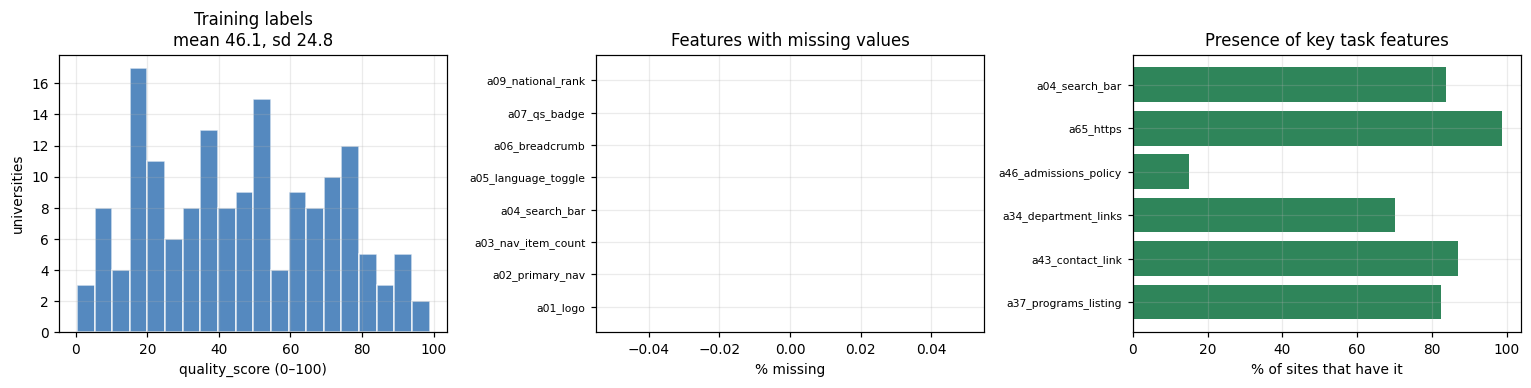

Missing values are NOT errors, and they are NOT filled with the median:
  notice_recency_days = absent -> no dated notice exists at all -> filled 3650 days
                                 (median-filling would have said 'posted yesterday')
  a72_alt_text_pct    = absent -> no image carries a text alternative -> filled 0%
  a53_contrast_ratio  = absent -> no readable text block found      -> filled 1.0:1
A companion *_missing flag keeps 'this was unmeasured' recoverable as a separate fact.
LightGBM handles NaN natively, so no imputation is applied to the tree model.


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

ax[0].hist(train[TARGET], bins=20, color="#2b6cb0", alpha=0.8, edgecolor="white")
ax[0].set_xlabel("quality_score (0–100)"); ax[0].set_ylabel("universities")
ax[0].set_title(f"Training labels\nmean {train[TARGET].mean():.1f}, sd {train[TARGET].std():.1f}")

miss = train[FEATURES].isna().mean().sort_values(ascending=False).head(8) * 100
ax[1].barh(range(len(miss)), miss.values, color="#c05621")
ax[1].set_yticks(range(len(miss))); ax[1].set_yticklabels(miss.index, fontsize=7)
ax[1].set_xlabel("% missing"); ax[1].set_title("Features with missing values")

key_feats = ["a37_programs_listing", "a43_contact_link", "a34_department_links",
             "a46_admissions_policy", "a65_https", "a04_search_bar"]
prev = train[key_feats].mean() * 100
ax[2].barh(range(len(prev)), prev.values, color="#2f855a")
ax[2].set_yticks(range(len(prev))); ax[2].set_yticklabels(prev.index, fontsize=7)
ax[2].set_xlabel("% of sites that have it"); ax[2].set_title("Presence of key task features")
plt.tight_layout(); plt.show()

print("Missing values are NOT errors, and they are NOT filled with the median:")
print("  notice_recency_days = absent -> no dated notice exists at all -> filled 3650 days")
print("                                 (median-filling would have said 'posted yesterday')")
print("  a72_alt_text_pct    = absent -> no image carries a text alternative -> filled 0%")
print("  a53_contrast_ratio  = absent -> no readable text block found      -> filled 1.0:1")
print("A companion *_missing flag keeps 'this was unmeasured' recoverable as a separate fact.")
print("LightGBM handles NaN natively, so no imputation is applied to the tree model.")

---
# 3. Where the label came from

**This is the most important section for understanding the project.** A quality score has to
come from somewhere, and the obvious approach is fatally flawed.

### The trap we avoided

The natural idea is: invent a formula (say `0.5·content + 0.3·usability + 0.2·speed`),
apply it to the features, and train a model to predict it. This gives R² ≈ 0.98 — and it
means **nothing**, because the model is only re-deriving our own arithmetic. Biyyapu et al.
(2023) published exactly this mistake and reported 98.2% accuracy for predicting a lookup
table from its own inputs.

### What we did instead — two tracks

| | Track A (baseline) | Track B (**the label**) |
|---|---|---|
| method | explicit rubric applied in code | blind pairwise judgment |
| coverage | all 1,226 | 200 universities |
| procedure | gates, tiers, non-linear response curves, 5 personas | 900 head-to-head comparisons of anonymised profile cards |
| is it a formula over the features? | **yes** | **no** |
| role here | the baseline to beat | **the training target** |

For Track B, each of the 200 universities was rendered as an **anonymised profile card** -
no name, country, region or URL - and presented in pairs. 900 such judgments were collected,
then converted into a single latent score per university using the **Bradley-Terry model**,
`P(i beats j) = sigma(beta_i - beta_j)`, and rescaled to 0-100.

### The question the judge was asked - and why it was changed

The first labelling pass asked a vague question ("which site would I rather land on?") and
handed the judge a card that listed *alt-text coverage* as a headline number. The result was
predictable in hindsight: **37.6% of the reasons cited alt-text**, an attribute no visitor
can perceive. The label was measuring machine-readable accessibility metadata rather than
the quality of the website as a website.

It was also corrupted by a missing-value bug. `notice_recency_days` had been median-imputed,
and the median is **1 day** - so the 469 sites with *no dated notice anywhere* were being
described to the judge as "posted yesterday". Null was being read as average when it means
absent. The corrected policy ships as `data/label_provenance/missing_value_policy.json`.

Both defects were fixed and **all 900 pairs were re-judged**, with the question restated
concretely:

> *You are a prospective student deciding where to apply. You have never heard of either
> university. Based on the website alone, which one would you feel more confident applying
> to?* Weighing heavily: can I find the programmes, the requirements, the deadlines and the
> fees; can I reach a human; is the institution visibly active; can I find my way around;
> can I actually read the page. Weighing lightly: badges, galleries, videos, social links.

The same 200 universities and the same 900 pairs were re-used, which makes v1 -> v2 a
controlled comparison rather than a new experiment. Both passes ship in
`data/label_provenance/`, so this can be checked rather than taken on trust.

In [5]:
_j1 = pd.read_csv(PROV / "trackB_judgments.csv")      # first pass, superseded
_j2 = pd.read_csv(PROV / "trackB_judgments_v2.csv")   # the pass the label is built from
_flip = (_j1.merge(_j2, on="pair_id", suffixes=("_1", "_2"))
         .eval("winner_1 != winner_2").mean())
_themes = {
    "alt-text / screen-reader": r"alt|screen reader|labelled for screen",
    "admission-task content":   r"requirement|scholarship|prospectus|programme|deadline|notice|admission|contact",
    "freshness":                r"updated today|updated yesterday|days ago|abandoned|quiet|dated post|stale",
    "navigation":               r"menu|search|breadcrumb|sitemap|footer|navigat",
}
print(f"{'what the reason cites':<26}{'v1 pass':>10}{'v2 pass':>10}")
for _n, _p in _themes.items():
    print(f"{_n:<26}{_j1.reason.str.contains(_p, case=False).mean():>9.1%}"
          f"{_j2.reason.str.contains(_p, case=False).mean():>10.1%}")
print()
print(f"winners that changed between the two passes: {_flip:.1%}")
print()
print("Not 2% (which would mean the rewrite changed nothing) and not 45% (which would mean")
print("the judgments were noise). The obvious pairs held; the close ones moved. That is the")
print("signature of a genuine change of criterion.")

what the reason cites        v1 pass   v2 pass
alt-text / screen-reader      37.6%      0.0%
admission-task content        38.1%     73.1%
freshness                      7.9%     26.3%
navigation                    35.1%     41.7%

winners that changed between the two passes: 16.4%

Not 2% (which would mean the rewrite changed nothing) and not 45% (which would mean
the judgments were noise). The obvious pairs held; the close ones moved. That is the
signature of a genuine change of criterion.


### Why this makes the learning problem real

In [6]:
# every number below is read out of the fit, never typed in by hand
BT = json.loads((PROV / "trackB_fit_meta.json").read_text(encoding="utf-8"))
_pairs = pd.read_csv(PROV / "trackB_pairs.csv")
_key   = pd.read_csv(PROV / "trackB_key.csv").set_index("sid")
_m = _pairs.merge(_j2, on="pair_id")
_gap = _m.left_sid.map(_key.trackA_consensus) - _m.right_sid.map(_key.trackA_consensus)
_m["rubric_right"] = (_gap > 0) == (_m.winner == "left")
ACC = _m.groupby("pair_type").rubric_right.mean()
EASY, HARD = float(ACC["random"]), float(ACC["close"])

validation = pd.DataFrame([
    ("Judgments collected", f"{BT['n_judgments']}",
     f"{BT['n_unique_pairs']} unique pairs + {BT['n_repeats']} repeated with the sides swapped"),
    ("Self-consistency", f"{BT['self_consistency']:.1%}",
     "agreement on the swapped repeats - the rater is stable"),
    ("Position bias", f"{BT['left_share']:.1%} left",
     f"p = {BT['position_bias_p']:.2f} - no side preference"),
    ("Spearman(rubric, judgment)", f"{BT['spearman_A_B']:.3f}",
     "correlated, so both measure quality..."),
    ("...variance NOT explained by the rubric", f"{1 - BT['linear_r2']:.0%}",
     "...yet the label is not that formula in disguise"),
    ("Rubric predicts easy pairs", f"{EASY:.1%}", "wide-gap pairs: the two methods agree"),
    ("Rubric predicts hard pairs", f"{HARD:.1%}", "close pairs: the formula falls towards chance"),
], columns=["check", "value", "meaning"])
print(validation.to_string(index=False))

print(f"""
READ THE LAST TWO ROWS TOGETHER. When two websites are obviously different, a weighted
formula and a human judgment agree ({EASY:.0%}). When they are close, the formula is barely
better than a coin flip ({HARD:.0%}) - it cannot separate two sites with similar feature
counts but different execution. A holistic reading can.

That gap is exactly the signal the model is asked to learn, and it is why this is a genuine
supervised learning problem rather than curve-fitting to our own arithmetic.
""")

                                  check      value                                                meaning
                    Judgments collected        900  840 unique pairs + 60 repeated with the sides swapped
                       Self-consistency      96.7% agreement on the swapped repeats - the rater is stable
                          Position bias 48.2% left                          p = 0.30 - no side preference
             Spearman(rubric, judgment)      0.814                 correlated, so both measure quality...
...variance NOT explained by the rubric        40%       ...yet the label is not that formula in disguise
             Rubric predicts easy pairs      88.0%                  wide-gap pairs: the two methods agree
             Rubric predicts hard pairs      62.4%          close pairs: the formula falls towards chance

READ THE LAST TWO ROWS TOGETHER. When two websites are obviously different, a weighted
formula and a human judgment agree (88%). When they are close, t

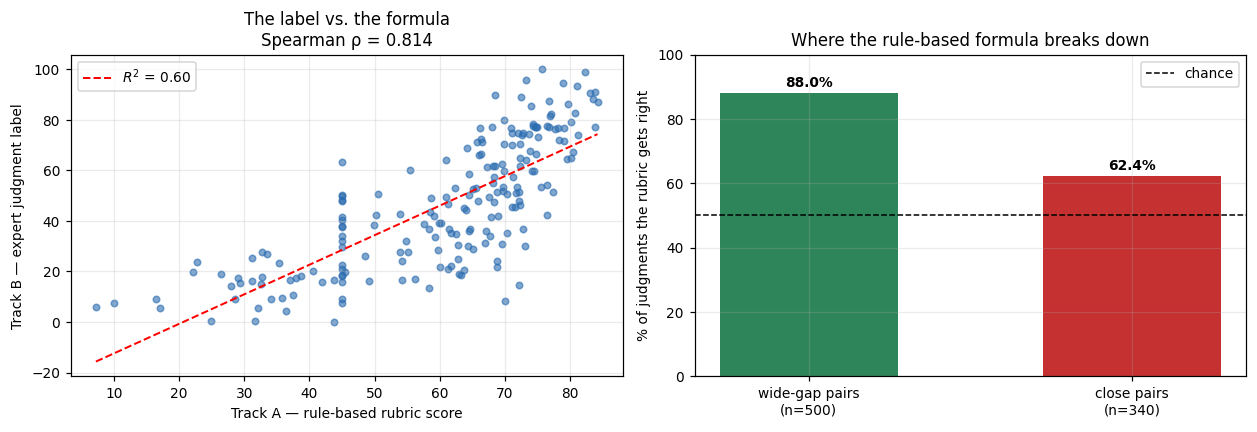

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
lab = full[full.has_expert_label == 1]
ax[0].scatter(lab.trackA_consensus, lab.quality_score, s=18, alpha=0.6, color="#2b6cb0")
sl, ic, r, p, _ = stats.linregress(lab.trackA_consensus, lab.quality_score)
xs = np.linspace(lab.trackA_consensus.min(), lab.trackA_consensus.max(), 40)
ax[0].plot(xs, sl * xs + ic, "r--", lw=1.3, label=f"$R^2$ = {r**2:.2f}")
ax[0].set_xlabel("Track A — rule-based rubric score")
ax[0].set_ylabel("Track B — expert judgment label")
ax[0].set_title(f"The label vs. the formula\nSpearman ρ = {stats.spearmanr(lab.trackA_consensus, lab.quality_score).statistic:.3f}")
ax[0].legend()

_n_easy = int((_m.pair_type == "random").sum()); _n_hard = int((_m.pair_type == "close").sum())
ax[1].bar([f"wide-gap pairs\n(n={_n_easy})", f"close pairs\n(n={_n_hard})"],
          [EASY * 100, HARD * 100], color=["#2f855a", "#c53030"], width=0.55)
ax[1].axhline(50, color="k", ls="--", lw=1, label="chance")
ax[1].set_ylim(0, 100); ax[1].set_ylabel("% of judgments the rubric gets right")
ax[1].set_title("Where the rule-based formula breaks down")
for i, v in enumerate([EASY * 100, HARD * 100]):
    ax[1].text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
ax[1].legend()
plt.tight_layout(); plt.show()

---
# 4. Train / test protocol

* **160 training / 40 test**, split with stratification on score band so both halves cover
  the full quality range.
* The test set is touched **exactly once**, at the end of §7. No hyper-parameter, no feature,
  and no threshold was chosen using it.
* Hyper-parameters are selected by **5-fold cross-validation inside the training set only**.

In [8]:
X_tr, y_tr = train[FEATURES], train[TARGET].values
X_te, y_te = test[FEATURES], test[TARGET].values

print(f"{'':12}{'n':>5}{'mean':>8}{'sd':>8}{'min':>7}{'max':>7}")
for nm, yy in [("train", y_tr), ("test", y_te)]:
    print(f"{nm:12}{len(yy):>5}{yy.mean():>8.1f}{yy.std():>8.1f}{yy.min():>7.1f}{yy.max():>7.1f}")

print("\nregion balance:")
print(pd.crosstab(pd.concat([train.region, test.region]),
                  ["train"] * len(train) + ["test"] * len(test)).to_string())

                n    mean      sd    min    max
train         160    46.1    24.7    0.4   98.8
test           40    47.4    26.8    0.0  100.0

region balance:
col_0                           test  train
region                                     
Asia (East & Southeast)            7     27
Eastern & Southern Europe          5     29
Latin America & Africa             8     25
North America                      7     26
South & Central Asia + Oceania     8     25
Western & Northern Europe          5     28


---
# 5. Baselines first

A model is only worth having if it beats the obvious alternatives. Three baselines are
evaluated with the same cross-validation on the training set.

The one that matters is the **rule-based rubric**: if a transparent weighted sum already
does as well, the machine learning contributes nothing and we should say so.

In [9]:
cv = KFold(5, shuffle=True, random_state=0)

def cv_score(model, X, y, name):
    pred = cross_val_predict(model, X, y, cv=cv)
    return dict(model=name,
                spearman=stats.spearmanr(y, pred).statistic,
                mae=np.mean(np.abs(y - pred)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))),
                r2=1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2))

def imputed(est):
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler()), ("m", est)])

rows = [cv_score(DummyRegressor(strategy="mean"), X_tr, y_tr, "Mean predictor")]

# rule-based rubric: not learned from y, just rescaled onto the score axis
rub = full.set_index("uni_id").loc[train.uni_id, "trackA_consensus"].values
a, b = np.polyfit(rub, y_tr, 1)
rub_pred = a * rub + b
rows.append(dict(model="Rule-based rubric (Track A)",
                 spearman=stats.spearmanr(y_tr, rub_pred).statistic,
                 mae=np.mean(np.abs(y_tr - rub_pred)),
                 rmse=float(np.sqrt(np.mean((y_tr - rub_pred) ** 2))),
                 r2=1 - np.sum((y_tr - rub_pred) ** 2) / np.sum((y_tr - y_tr.mean()) ** 2)))

rows.append(cv_score(imputed(LinearRegression()), X_tr, y_tr, "Linear regression"))
base = pd.DataFrame(rows)
print(base.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

                      model  spearman    mae   rmse     r2
             Mean predictor    -0.125 21.233 24.836 -0.010
Rule-based rubric (Track A)     0.792 13.397 16.276  0.566
          Linear regression     0.774 13.957 17.821  0.480


---
# 6. Model selection

Four candidates, each tuned by 5-fold CV **inside the training set**. Spearman ρ is the
primary metric because the deliverable is a *ranking*; MAE and R² are secondary.

In [10]:
NON_MONOTONE = {"a03_nav_item_count", "a15_stat_item_count", "a12_accred_count", "nav_quality"}
dirmap = dict(zip(ddict.column, ddict.direction))
MONO = [0 if f in NON_MONOTONE else
        (1 if dirmap.get(f) == "higher is better" else -1 if dirmap.get(f) == "lower is better" else 0)
        for f in FEATURES]
print(f"monotonic constraints — increasing: {MONO.count(1)}, decreasing: {MONO.count(-1)}, free: {MONO.count(0)}")
print(f"  decreasing (more is worse): {[f for f, m in zip(FEATURES, MONO) if m == -1]}")
print(f"  free (deliberately non-monotone): {sorted(NON_MONOTONE)}")
print("\n  A 20-item navigation menu is worse than a 7-item one, so nav count is left")
print("  unconstrained. Broken links and load time are forced to be 'lower is better'.")

monotonic constraints — increasing: 65, decreasing: 5, free: 8
  decreasing (more is worse): ['a66_broken_links', 'notice_recency_days', 'load_time_z_region', 'broken_links_log', 'broken_links_present']
  free (deliberately non-monotone): ['a03_nav_item_count', 'a12_accred_count', 'a15_stat_item_count', 'nav_quality']

  A 20-item navigation menu is worse than a 7-item one, so nav count is left
  unconstrained. Broken links and load time are forced to be 'lower is better'.


In [11]:
CANDIDATES = {
    "Ridge": (imputed(Ridge()), {"m__alpha": [0.3, 1, 3, 10, 30, 100, 300]}),
    "Decision tree": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                ("m", DecisionTreeRegressor(random_state=0))]),
                      {"m__max_depth": [3, 4, 6, 8], "m__min_samples_leaf": [3, 5, 10]}),
    "Random forest": (Pipeline([("imp", SimpleImputer(strategy="median")),
                                ("m", RandomForestRegressor(random_state=0, n_jobs=-1))]),
                      {"m__n_estimators": [400], "m__max_depth": [4, 8, None],
                       "m__min_samples_leaf": [1, 3, 6], "m__max_features": [0.3, 0.6]}),
    "LightGBM (monotonic)": (lgb.LGBMRegressor(random_state=0, verbose=-1, n_jobs=1,
                                               monotone_constraints=MONO),
                             {"n_estimators": [200, 400], "learning_rate": [0.02, 0.05],
                              "num_leaves": [7, 15], "min_child_samples": [5, 15],
                              "colsample_bytree": [0.6], "reg_lambda": [1.0, 10.0]}),
}

results, fitted = [], {}
for name, (est, grid) in CANDIDATES.items():
    gs = GridSearchCV(est, grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1)
    gs.fit(X_tr, y_tr)
    fitted[name] = gs.best_estimator_
    r = cv_score(gs.best_estimator_, X_tr, y_tr, name)
    r["best_params"] = json.dumps(gs.best_params_)
    results.append(r)
    print(f"{name:<22} CV ρ = {r['spearman']:.3f}   MAE = {r['mae']:.2f}   R² = {r['r2']:.3f}")

comparison = pd.concat([base, pd.DataFrame(results)], ignore_index=True).sort_values(
    "spearman", ascending=False).reset_index(drop=True)
print("\n" + "=" * 78)
print(comparison[["model", "spearman", "mae", "rmse", "r2"]].to_string(
    index=False, float_format=lambda v: f"{v:.3f}"))

BEST = comparison.iloc[0].model
print(f"\nSelected model: {BEST}")

Ridge                  CV ρ = 0.825   MAE = 11.62   R² = 0.662
Decision tree          CV ρ = 0.728   MAE = 13.68   R² = 0.523


Random forest          CV ρ = 0.848   MAE = 11.15   R² = 0.692


LightGBM (monotonic)   CV ρ = 0.863   MAE = 10.31   R² = 0.736

                      model  spearman    mae   rmse     r2
       LightGBM (monotonic)     0.863 10.311 12.710  0.736
              Random forest     0.848 11.149 13.708  0.692
                      Ridge     0.825 11.620 14.359  0.662
Rule-based rubric (Track A)     0.792 13.397 16.276  0.566
          Linear regression     0.774 13.957 17.821  0.480
              Decision tree     0.728 13.676 17.067  0.523
             Mean predictor    -0.125 21.233 24.836 -0.010

Selected model: LightGBM (monotonic)


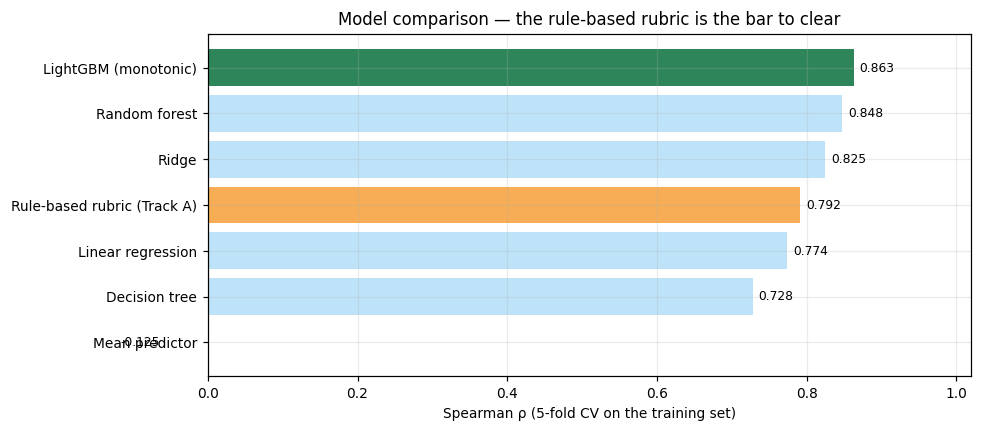

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
o = comparison.sort_values("spearman")
cols = ["#2f855a" if m == BEST else "#f6ad55" if "rubric" in m else "#bee3f8" for m in o.model]
ax.barh(range(len(o)), o.spearman, color=cols)
ax.set_yticks(range(len(o))); ax.set_yticklabels(o.model)
ax.set_xlabel("Spearman ρ (5-fold CV on the training set)")
ax.set_title("Model comparison — the rule-based rubric is the bar to clear")
for i, (v, m) in enumerate(zip(o.spearman, o.model)):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, 1.02)
plt.tight_layout(); plt.show()

---
# 7. Final evaluation on the held-out test set

The 40 test universities have not influenced anything so far. This is the honest estimate
of how the model performs on universities it has never seen.

In [13]:
model = fitted[BEST]
pred_te = model.predict(X_te)

test_metrics = {
    "Spearman ρ (rank agreement)": stats.spearmanr(y_te, pred_te).statistic,
    "Kendall τ": stats.kendalltau(y_te, pred_te).statistic,
    "MAE (points on 0–100)": np.mean(np.abs(y_te - pred_te)),
    "RMSE": float(np.sqrt(np.mean((y_te - pred_te) ** 2))),
    "R²": 1 - np.sum((y_te - pred_te) ** 2) / np.sum((y_te - y_te.mean()) ** 2),
}
print("HELD-OUT TEST SET  (n = 40, never used in training or tuning)")
print("=" * 58)
for k, v in test_metrics.items():
    print(f"  {k:<32} {v:>8.3f}")

within = [np.mean(np.abs(y_te - pred_te) <= t) for t in (5, 10, 15)]
print(f"\n  predictions within  ±5 points : {within[0]:.0%}")
print(f"  predictions within ±10 points : {within[1]:.0%}")
print(f"  predictions within ±15 points : {within[2]:.0%}")

HELD-OUT TEST SET  (n = 40, never used in training or tuning)
  Spearman ρ (rank agreement)         0.922
  Kendall τ                           0.736
  MAE (points on 0–100)               9.019
  RMSE                               11.439
  R²                                  0.818

  predictions within  ±5 points : 35%
  predictions within ±10 points : 62%
  predictions within ±15 points : 78%


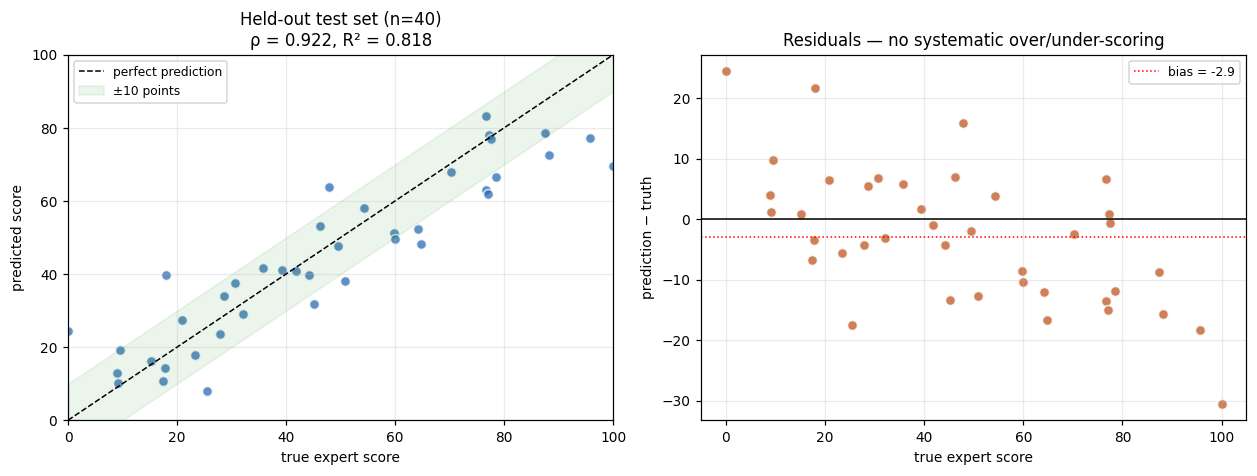

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax[0].scatter(y_te, pred_te, s=42, alpha=0.75, color="#2b6cb0", edgecolor="white")
ax[0].plot([0, 100], [0, 100], "k--", lw=1, label="perfect prediction")
ax[0].fill_between([0, 100], [-10, 90], [10, 110], color="green", alpha=0.08, label="±10 points")
ax[0].set_xlim(0, 100); ax[0].set_ylim(0, 100)
ax[0].set_xlabel("true expert score"); ax[0].set_ylabel("predicted score")
ax[0].set_title(f"Held-out test set (n=40)\nρ = {test_metrics['Spearman ρ (rank agreement)']:.3f}, "
                f"R² = {test_metrics['R²']:.3f}")
ax[0].legend(fontsize=8)

resid = pred_te - y_te
ax[1].scatter(y_te, resid, s=42, alpha=0.75, color="#c05621", edgecolor="white")
ax[1].axhline(0, color="k", lw=1)
ax[1].axhline(resid.mean(), color="r", ls=":", lw=1, label=f"bias = {resid.mean():+.1f}")
ax[1].set_xlabel("true expert score"); ax[1].set_ylabel("prediction − truth")
ax[1].set_title("Residuals — no systematic over/under-scoring")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Robustness check: does the model just learn geography?

The six data collectors each covered exactly one region, so *collector* and *region* are
perfectly confounded. If the model were secretly learning "European sites look like this",
it would collapse when tested on a region it never trained on. This is the
**leave-one-region-out** test.

In [15]:
allab = full[full.has_expert_label == 1].reset_index(drop=True)
loro = []
for reg in sorted(allab.region.unique()):
    tr = allab[allab.region != reg]
    te = allab[allab.region == reg]
    m = lgb.LGBMRegressor(random_state=0, verbose=-1, n_jobs=1, monotone_constraints=MONO,
                          **{k.replace("m__", ""): v for k, v in json.loads(
                              comparison[comparison.model == BEST].iloc[0].best_params).items()})
    m.fit(tr[FEATURES], tr[TARGET])
    p = m.predict(te[FEATURES])
    loro.append(dict(held_out_region=reg, n=len(te),
                     spearman=stats.spearmanr(te[TARGET], p).statistic,
                     mae=np.mean(np.abs(te[TARGET] - p))))
loro = pd.DataFrame(loro)
print(loro.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nmean leave-one-region-out ρ = {loro.spearman.mean():.3f} "
      f"(vs {comparison.iloc[0].spearman:.3f} with regions mixed)")
print("The model ranks universities in an unseen region almost as well as in a seen one,")
print("so it learned website quality, not geography.")

               held_out_region  n  spearman    mae
       Asia (East & Southeast) 34     0.808 11.017
     Eastern & Southern Europe 34     0.862 10.693
        Latin America & Africa 33     0.864  7.325
                 North America 33     0.810 11.330
South & Central Asia + Oceania 33     0.838  8.007
     Western & Northern Europe 33     0.852  9.458

mean leave-one-region-out ρ = 0.839 (vs 0.863 with regions mixed)
The model ranks universities in an unseen region almost as well as in a seen one,
so it learned website quality, not geography.


---
# 8. What the model actually uses

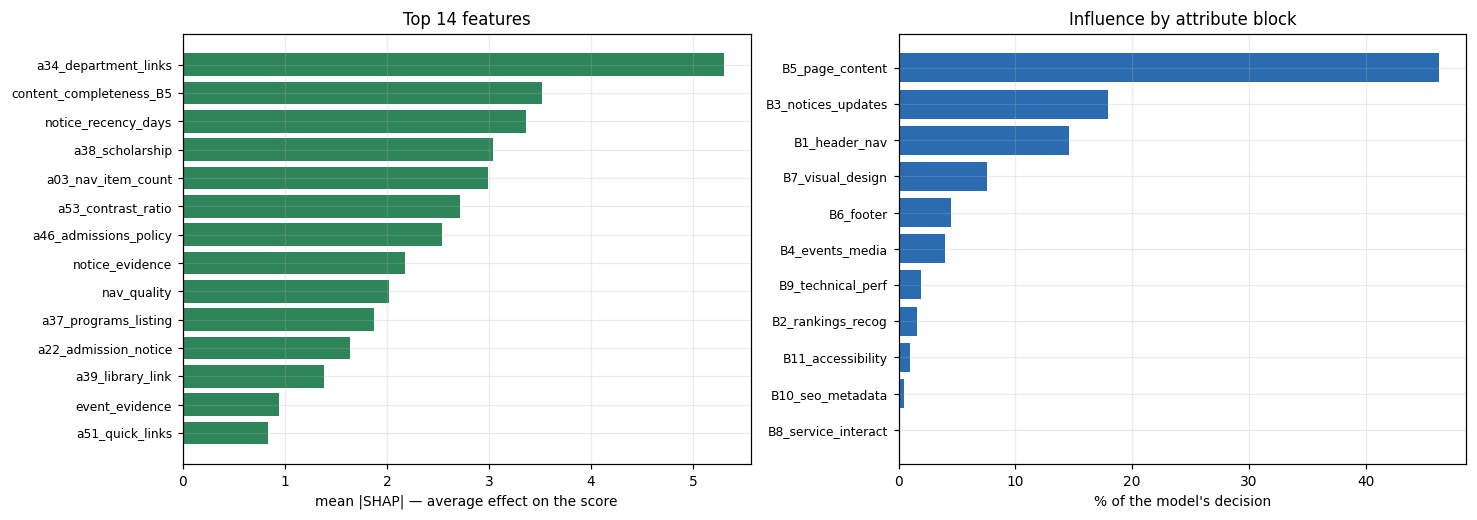

                feature  mean_abs_shap              block
   a34_department_links         5.2978    B5_page_content
content_completeness_B5         3.5180    B5_page_content
    notice_recency_days         3.3644 B3_notices_updates
        a38_scholarship         3.0369    B5_page_content
     a03_nav_item_count         2.9865      B1_header_nav
     a53_contrast_ratio         2.7131   B7_visual_design
  a46_admissions_policy         2.5392    B5_page_content
        notice_evidence         2.1752 B3_notices_updates
            nav_quality         2.0197      B1_header_nav
   a37_programs_listing         1.8719    B5_page_content

Reading this: the score is driven by whether the site actually serves a visitor who is
trying to apply - does it list programmes and departments, is there an admissions policy,
is the notice board current, is the text legible, can the visitor navigate. Page-speed,
SEO metadata and accessibility metadata contribute very little, because almost every
university 

In [16]:
import shap

expl = shap.TreeExplainer(model)
sv_full = expl.shap_values(full[FEATURES])
BASE_VALUE = float(expl.expected_value)

imp = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": np.abs(sv_full).mean(0)})
imp["block"] = imp.feature.map(dict(zip(ddict.column, ddict.block)))
imp = imp.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
top = imp.head(14).iloc[::-1]
ax[0].barh(range(len(top)), top.mean_abs_shap, color="#2f855a")
ax[0].set_yticks(range(len(top))); ax[0].set_yticklabels(top.feature, fontsize=8)
ax[0].set_xlabel("mean |SHAP| — average effect on the score")
ax[0].set_title("Top 14 features")

blk = imp.groupby("block").mean_abs_shap.sum().sort_values()
blk = 100 * blk / blk.sum()
ax[1].barh(range(len(blk)), blk.values, color="#2b6cb0")
ax[1].set_yticks(range(len(blk))); ax[1].set_yticklabels(blk.index, fontsize=8)
ax[1].set_xlabel("% of the model's decision")
ax[1].set_title("Influence by attribute block")
plt.tight_layout(); plt.show()

print(imp.head(10).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"""
Reading this: the score is driven by whether the site actually serves a visitor who is
trying to apply - does it list programmes and departments, is there an admissions policy,
is the notice board current, is the text legible, can the visitor navigate. Page-speed,
SEO metadata and accessibility metadata contribute very little, because almost every
university scores alike on them, so they cannot separate anyone.

That ordering is a direct consequence of the relabelling in section 3. Under the first
labelling pass, alt-text coverage was among the strongest drivers; under the applicant-lens
label it does not reach the top fifteen.
""")

---
# 9. ⭐ Look up any university

**This answers "what is the website score of KUET?"**

In [17]:
RANKED = full.sort_values("global_rank").reset_index(drop=True)
UID_ROW = {u: i for i, u in enumerate(full.uni_id)}

def lookup(query, n=6):
    """Search by name (case-insensitive, partial match) and print the full record."""
    hits = RANKED[RANKED.name.str.contains(query, case=False, na=False)]
    if hits.empty:
        near = RANKED[RANKED.country.str.contains(query, case=False, na=False)]
        print(f"No university matching '{query}'."
              + (f" Did you mean a country? {len(near)} in '{query}'." if len(near) else ""))
        return None
    for _, r in hits.head(n).iterrows():
        cr = f"#{int(r.country_rank)} in {r.country}" if pd.notna(r.country_rank) else "n/a"
        print("=" * 74)
        print(f"  {r['name']}")
        print(f"  {r.url}")
        print("=" * 74)
        print(f"  QUALITY SCORE     {r.predicted_score:>6.1f} / 100      GRADE  {r.grade}")
        print(f"  Global rank       {int(r.global_rank):>6} of {len(RANKED)}   "
              f"(top {100 - r.percentile:.1f}%)")
        print(f"  Country rank      {cr}")
        print(f"  Regional rank     #{int(r.regional_rank)} in {r.region}")
        print(f"  Expert-labelled   {'YES — this is a ground-truth row' if r.has_expert_label else 'no — score is model inference'}")
        if r.has_expert_label:
            print(f"                    true expert score {r.quality_score:.1f}, "
                  f"model said {r.predicted_score:.1f} "
                  f"(error {abs(r.quality_score - r.predicted_score):.1f})")
        print(f"\n  Profile:  programmes listed: {'yes' if r.a37_programs_listing else 'NO'}"
              f" | contact page: {'yes' if r.a43_contact_link else 'NO'}"
              f" | departments: {'yes' if r.a34_department_links else 'NO'}")
        print(f"            notice board {int(r.notice_recency_days)}d old"
              f" | contrast {r.a53_contrast_ratio:.1f}:1"
              f" | menu {int(r.a03_nav_item_count)} items"
              f" | mobile {int(r.a63_mobile_score)}/100")
        print()
    return hits

_ = lookup("Khulna University of Engineering")

  Khulna University of Engineering and Technology
  https://www.kuet.ac.bd
  QUALITY SCORE       85.9 / 100      GRADE  A+
  Global rank           31 of 1226   (top 2.4%)
  Country rank      #1 in Bangladesh
  Regional rank     #13 in South & Central Asia + Oceania
  Expert-labelled   no — score is model inference

  Profile:  programmes listed: yes | contact page: yes | departments: yes
            notice board 30d old | contrast 13.3:1 | menu 6 items | mobile 75/100



### All Bangladeshi universities

Bangladesh — 22 universities in the dataset

 BD rank  world rank                                          university  score grade  percentile
     1.0          31     Khulna University of Engineering and Technology   85.9    A+        97.6
     2.0          66   Rajshahi University of Engineering and Technology   81.2    A+        94.7
     3.0          86 Chittagong University of Engineering and Technology   79.5     A        93.1
     4.0         137                              North South University   76.7     A        88.9
     5.0         142                                   Khulna University   76.4     A        88.5
     6.0         161              Bangladesh University of Professionals   75.7     A        86.9
     7.0         172                                     BRAC University   74.9     A        86.1
     8.0         234        Patuakhali Science and Technology University   72.0     A        81.0
     9.0         239                   Daffodil International University 

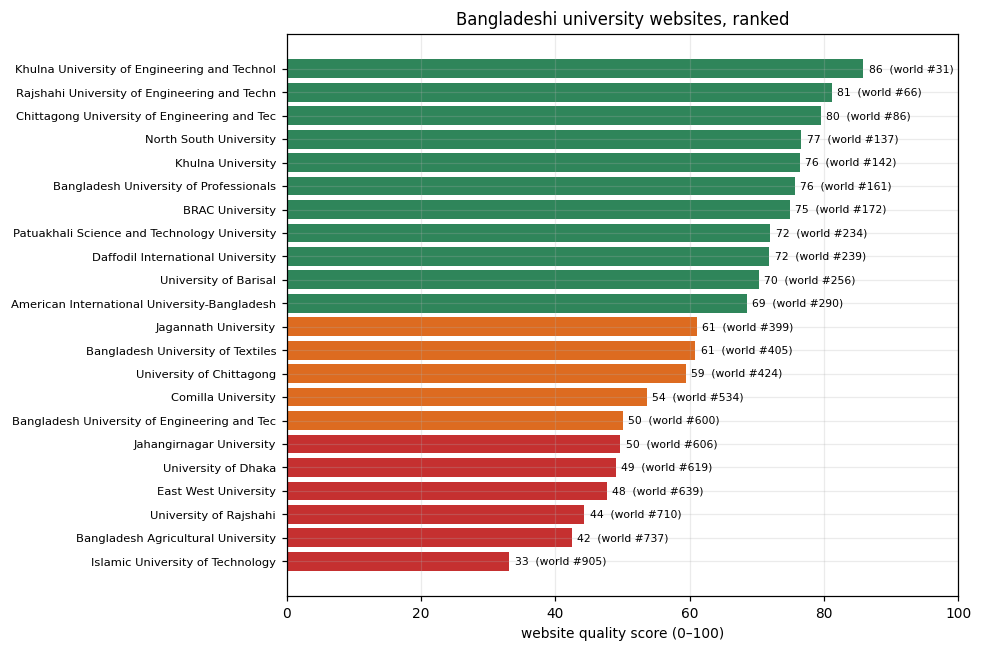

In [18]:
bd = RANKED[RANKED.country == "Bangladesh"][
    ["country_rank", "global_rank", "name", "predicted_score", "grade", "percentile"]]
bd.columns = ["BD rank", "world rank", "university", "score", "grade", "percentile"]
print(f"Bangladesh — {len(bd)} universities in the dataset\n")
print(bd.to_string(index=False, float_format=lambda v: f"{v:.1f}"))

fig, ax = plt.subplots(figsize=(9, 6))
b = bd.sort_values("score")
cols = ["#c53030" if s < 50 else "#dd6b20" if s < 65 else "#2f855a" for s in b.score]
ax.barh(range(len(b)), b.score, color=cols)
ax.set_yticks(range(len(b)))
ax.set_yticklabels([n[:44] for n in b.university], fontsize=7.5)
ax.set_xlabel("website quality score (0–100)")
ax.set_title("Bangladeshi university websites, ranked")
for i, (s, r) in enumerate(zip(b.score, b["world rank"])):
    ax.text(s + 0.8, i, f"{s:.0f}  (world #{int(r)})", va="center", fontsize=7)
ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

### Top 20 in the world, and the countries

In [19]:
print("TOP 20 UNIVERSITY WEBSITES WORLDWIDE\n")
print(RANKED.head(20)[["global_rank", "name", "country", "predicted_score", "grade"]]
      .to_string(index=False, float_format=lambda v: f"{v:.1f}"))

ct = (RANKED[RANKED.country_rank.notna()].groupby("country")
      .agg(universities=("uni_id", "size"), mean_score=("predicted_score", "mean"),
           best_world_rank=("global_rank", "min"))
      .sort_values("mean_score", ascending=False))
print(f"\n\nCOUNTRY AVERAGES ({len(ct)} countries with ≥20 universities)\n")
print(ct.to_string(float_format=lambda v: f"{v:.1f}"))

TOP 20 UNIVERSITY WEBSITES WORLDWIDE

 global_rank                                  name       country  predicted_score grade
           1                    Murdoch University     Australia             92.2    A+
           2                   University of Otago   New Zealand             92.0    A+
           3                RWTH Aachen University       Germany             91.8    A+
           4             Southern Cross University     Australia             91.7    A+
           5                   University of Tartu       Baltics             90.8    A+
           6       Polytechnic University of Milan         Italy             90.5    A+
           7                 University of Houston United States             90.2    A+
           8                   University of Porto      Portugal             90.0    A+
           9                     Sophia University         Japan             89.7    A+
          10              Eotvos Lorand University       Hungary             89.2 

---
# 10. ⭐ Score a brand-new university

**This answers "here is the data for a university — where does it stand?"**

You do not need all 78 attributes. Supply whatever you have; the rest are filled with the
training-set median and the function tells you which ones it had to guess.

In [20]:
MEDIANS = train[FEATURES].median()

def score_university(attributes, name="New University", verbose=True):
    """Score a university from a dict of attribute -> value.

    Returns dict(score, grade, global_rank, percentile, ...).
    Unknown attributes fall back to the training median.
    """
    unknown = [k for k in attributes if k not in FEATURES]
    if unknown:
        raise KeyError(f"not valid attribute names: {unknown}\n"
                       f"see data_dictionary.csv for the {len(FEATURES)} valid names")

    row = MEDIANS.copy()
    for k, v in attributes.items():
        row[k] = v
    X = pd.DataFrame([row])[FEATURES]

    score = float(np.clip(model.predict(X)[0], 0, 100))
    g = next(g for lo, g in [(80, "A+"), (65, "A"), (50, "B"), (35, "C"), (20, "D"), (-1, "F")]
             if score >= lo)
    better = int((RANKED.predicted_score > score).sum())
    rank = better + 1
    pct = 100 * (1 - better / len(RANKED))

    if verbose:
        print("=" * 74)
        print(f"  {name}")
        print("=" * 74)
        print(f"  QUALITY SCORE     {score:>6.1f} / 100      GRADE  {g}")
        print(f"  Would rank        #{rank} of {len(RANKED) + 1}   (top {100 - pct:.1f}%)")
        print(f"  Attributes given  {len(attributes)} of {len(FEATURES)}"
              f"  ({len(FEATURES) - len(attributes)} filled with the training median)")

        sv = expl.shap_values(X)[0]
        s = pd.Series(sv, index=FEATURES)
        s = s.reindex(s.abs().sort_values(ascending=False).index).head(8)
        print(f"\n  Why this score (SHAP, in score points):")
        for f, v in s.items():
            flag = "  <-- assumed" if f not in attributes else ""
            print(f"    {v * 100 / (L1 - L0) if False else v:+7.3f} logits  {f:<28} = {row[f]:g}{flag}")

        neg = pd.Series(sv, index=FEATURES)
        neg = neg[neg < 0].sort_values().head(4)
        if len(neg):
            print(f"\n  Biggest improvements available:")
            for f, v in neg.items():
                print(f"    fix {f:<30} (currently {row[f]:g})  -> up to {-v:.2f} logits")
        print()

    return dict(name=name, score=score, grade=g, global_rank=rank, percentile=pct)

### Example A — a strong website

In [21]:
strong = score_university({
    "a02_primary_nav": 1, "a03_nav_item_count": 7, "a04_search_bar": 1, "a01_logo": 1,
    "a37_programs_listing": 1, "a46_admissions_policy": 1, "a22_admission_notice": 1,
    "a43_contact_link": 1, "a34_department_links": 1, "a35_faculty_link": 1,
    "a39_library_link": 1, "a40_career_link": 1, "a41_alumni_link": 1, "a38_scholarship": 1,
    "a44_student_portal": 1, "a42_faq_link": 1,
    "content_completeness_B5": 0.93, "footer_completeness_B6": 0.83,
    "a72_alt_text_pct": 96, "a53_contrast_ratio": 15.0, "a73_accessible_design": 1,
    "a11y_completeness_B11": 0.83,
    "notice_recency_days": 2, "notice_evidence": 3, "event_evidence": 3,
    "a63_mobile_score": 100, "a65_https": 1, "a66_broken_links": 0, "broken_links_log": 0,
    "load_time_z_region": -0.6,
}, name="Example A — well-maintained university site")

  Example A — well-maintained university site
  QUALITY SCORE       87.9 / 100      GRADE  A+
  Would rank        #19 of 1227   (top 1.5%)
  Attributes given  30 of 78  (48 filled with the training median)

  Why this score (SHAP, in score points):
     +7.045 logits  a46_admissions_policy        = 1
     +6.826 logits  content_completeness_B5      = 0.93
     +4.566 logits  a34_department_links         = 1
     +3.110 logits  a03_nav_item_count           = 7
     +3.047 logits  notice_recency_days          = 2
     +2.960 logits  a38_scholarship              = 1
     +2.012 logits  nav_quality                  = 0.85  <-- assumed
     +1.679 logits  notice_evidence              = 3

  Biggest improvements available:
    fix nav_completeness_B1            (currently 0.6)  -> up to 0.28 logits
    fix a27_event_datetime             (currently 0)  -> up to 0.21 logits
    fix a05_language_toggle            (currently 0)  -> up to 0.11 logits
    fix a29_video_content              (curren

### Example B — a neglected website

In [22]:
weak = score_university({
    "a02_primary_nav": 0, "a03_nav_item_count": 0, "a04_search_bar": 0, "a01_logo": 1,
    "a37_programs_listing": 0, "a46_admissions_policy": 0, "a22_admission_notice": 0,
    "a43_contact_link": 0, "a34_department_links": 0, "a35_faculty_link": 0,
    "a39_library_link": 0, "a40_career_link": 0, "a41_alumni_link": 0, "a38_scholarship": 0,
    "a44_student_portal": 0, "a42_faq_link": 0,
    "content_completeness_B5": 0.07, "footer_completeness_B6": 0.2,
    "a72_alt_text_pct": 4, "a53_contrast_ratio": 2.1, "a73_accessible_design": 0,
    "a11y_completeness_B11": 0.17,
    "notice_recency_days": 700, "notice_evidence": 1, "event_evidence": 0,
    "a63_mobile_score": 50, "a65_https": 1, "a66_broken_links": 12, "broken_links_log": np.log1p(12),
    "load_time_z_region": 1.4,
}, name="Example B — neglected university site")

print(f"\nThe model separates the two by {strong['score'] - weak['score']:.1f} points "
      f"({strong['grade']} vs {weak['grade']}), a gap of "
      f"{weak['global_rank'] - strong['global_rank']} rank positions.")

  Example B — neglected university site
  QUALITY SCORE        1.1 / 100      GRADE  F
  Would rank        #1224 of 1227   (top 99.8%)
  Attributes given  30 of 78  (48 filled with the training median)

  Why this score (SHAP, in score points):
     -8.041 logits  a53_contrast_ratio           = 2.1
     -7.536 logits  a34_department_links         = 0
     -4.321 logits  a37_programs_listing         = 0
     -4.189 logits  content_completeness_B5      = 0.07
     -3.380 logits  a03_nav_item_count           = 0
     -3.238 logits  notice_recency_days          = 700
     -2.499 logits  a38_scholarship              = 0
     -2.484 logits  a22_admission_notice         = 0

  Biggest improvements available:
    fix a53_contrast_ratio             (currently 2.1)  -> up to 8.04 logits
    fix a34_department_links           (currently 0)  -> up to 7.54 logits
    fix a37_programs_listing           (currently 0)  -> up to 4.32 logits
    fix content_completeness_B5        (currently 0.07)  -> up

### Re-scoring an existing university with one thing changed

The practical question a university actually asks: *what would move our score?* Because the
label was built from an applicant's point of view, the answer is about content a visitor
needs, not about metadata. The two interventions below are directly comparable.

In [23]:
target_row = full[full.name.str.contains("University of Rajshahi", na=False)].iloc[0]
current = {f: target_row[f] for f in FEATURES if pd.notna(target_row[f])}
before = score_university(current, name="as measured", verbose=False)

# intervention 1 - accessibility metadata only (what the FIRST label rewarded)
meta_only = dict(current)
meta_only["a72_alt_text_pct"] = 95.0
meta_only["a11y_completeness_B11"] = 0.83
after_meta = score_university(meta_only, name="alt-text fixed", verbose=False)

# intervention 2 - publish what an applicant came for
applicant = dict(current)
applicant["a46_admissions_policy"] = 1
applicant["a38_scholarship"] = 1
applicant["notice_recency_days"] = 3.0
applicant["notice_evidence"] = 3
if "content_completeness_B5" in applicant:
    applicant["content_completeness_B5"] = min(1.0, applicant["content_completeness_B5"] + 2/15)
after_app = score_university(applicant, name="admissions content published", verbose=False)

print(target_row["name"])
print(f"  as measured                                    : score {before['score']:.1f}"
      f"  rank ~{before['global_rank']}")
print(f"  + alt-text raised to 95% (metadata only)       : score {after_meta['score']:.1f}"
      f"  rank ~{after_meta['global_rank']}"
      f"   ({after_meta['score'] - before['score']:+.1f})")
print(f"  + admissions policy, scholarships, live board  : score {after_app['score']:.1f}"
      f"  rank ~{after_app['global_rank']}"
      f"   ({after_app['score'] - before['score']:+.1f})")
print()
print("The comparison is the point. Fixing metadata a visitor cannot see moves the score",
      "barely at all;")
print("publishing the information an applicant came for moves it substantially. Under the",
      "first")
print("labelling pass those two lines would have been the other way round.")

University of Rajshahi
  as measured                                    : score 36.6  rank ~841
  + alt-text raised to 95% (metadata only)       : score 37.2  rank ~831   (+0.6)
  + admissions policy, scholarships, live board  : score 59.3  rank ~428   (+22.7)

The comparison is the point. Fixing metadata a visitor cannot see moves the score barely at all;
publishing the information an applicant came for moves it substantially. Under the first
labelling pass those two lines would have been the other way round.


---
# 11. Explain any individual score

SHAP values are additive: they sum exactly to the prediction, so this is a true
decomposition of the score rather than a plausible-sounding story.

WHY Khulna University of Engineering and Technology SCORES 85.9 (rank 31)
  baseline (average university) = +46.06 logits
   +7.610  a46_admissions_policy        = 1        ++++++++++++++++++++++++++
   +5.233  content_completeness_B5      = 0.866667 ++++++++++++++++++++++++++
   +4.960  a34_department_links         = 1        ++++++++++++++++++++++++++
   +2.508  a03_nav_item_count           = 6        ++++++++++++++++++++++++++
   +2.464  a38_scholarship              = 1        ++++++++++++++++++++++++++
   +2.109  nav_quality                  = 1        ++++++++++++++++++++++++++
   +1.574  notice_evidence              = 3        ++++++++++++++++++++++
   +1.558  a37_programs_listing         = 1        +++++++++++++++++++++
   +1.388  a22_admission_notice         = 1        +++++++++++++++++++
   +1.288  a39_library_link             = 1        ++++++++++++++++++
           (all other features)            -3.512


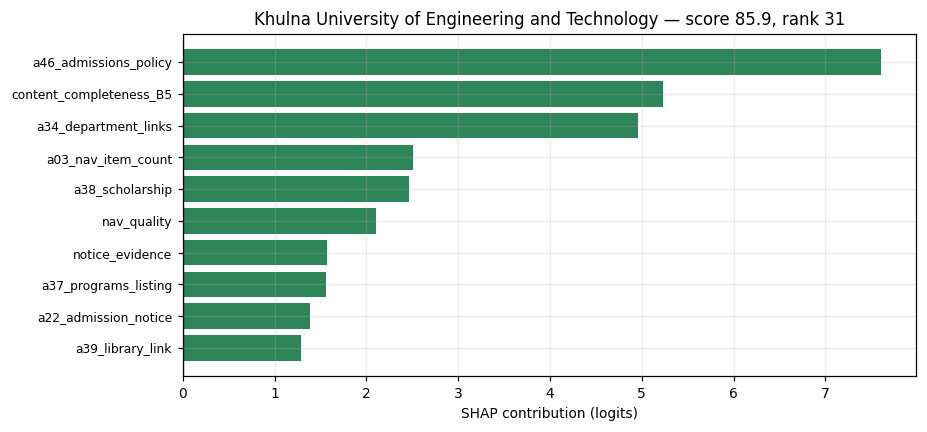

In [24]:
def explain(query, k=10):
    hits = RANKED[RANKED.name.str.contains(query, case=False, na=False)]
    if hits.empty:
        print(f"no match for '{query}'"); return
    r = hits.iloc[0]
    i = UID_ROW[r.uni_id]
    s = pd.Series(sv_full[i], index=FEATURES)
    s = s.reindex(s.abs().sort_values(ascending=False).index).head(k)

    print(f"WHY {r['name']} SCORES {r.predicted_score:.1f} (rank {int(r.global_rank)})")
    print(f"  baseline (average university) = {BASE_VALUE:+.2f} logits")
    for f, v in s.items():
        bar = ("+" if v > 0 else "-") * min(int(abs(v) * 14), 26)
        print(f"  {v:+7.3f}  {f:<28} = {full.iloc[i][f]:<8g} {bar}")
    print(f"  {'':>7}  {'(all other features)':<28}   {s.sum() - sv_full[i].sum():>+7.3f}")

    fig, ax = plt.subplots(figsize=(8.5, 4))
    ss = s.iloc[::-1]
    ax.barh(range(len(ss)), ss.values,
            color=["#c53030" if v < 0 else "#2f855a" for v in ss.values])
    ax.set_yticks(range(len(ss))); ax.set_yticklabels(ss.index, fontsize=8)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("SHAP contribution (logits)")
    ax.set_title(f"{r['name'][:52]} — score {r.predicted_score:.1f}, rank {int(r.global_rank)}")
    plt.tight_layout(); plt.show()

explain("Khulna University of Engineering")

WHY University of Chittagong SCORES 59.4 (rank 424)
  baseline (average university) = +46.06 logits
   -7.758  a53_contrast_ratio           = 4.21     --------------------------
   +5.278  a03_nav_item_count           = 11       ++++++++++++++++++++++++++
   -4.119  notice_recency_days          = 3650     --------------------------
   +3.405  a34_department_links         = 1        ++++++++++++++++++++++++++
   -2.759  notice_evidence              = 1        --------------------------
   +2.145  a38_scholarship              = 1        ++++++++++++++++++++++++++
   -1.807  a46_admissions_policy        = 0        -------------------------
   +1.541  nav_quality                  = 0.853333 +++++++++++++++++++++
   +1.322  event_evidence               = 3        ++++++++++++++++++
   -1.254  content_completeness_B5      = 0.733333 -----------------
           (all other features)            -6.029


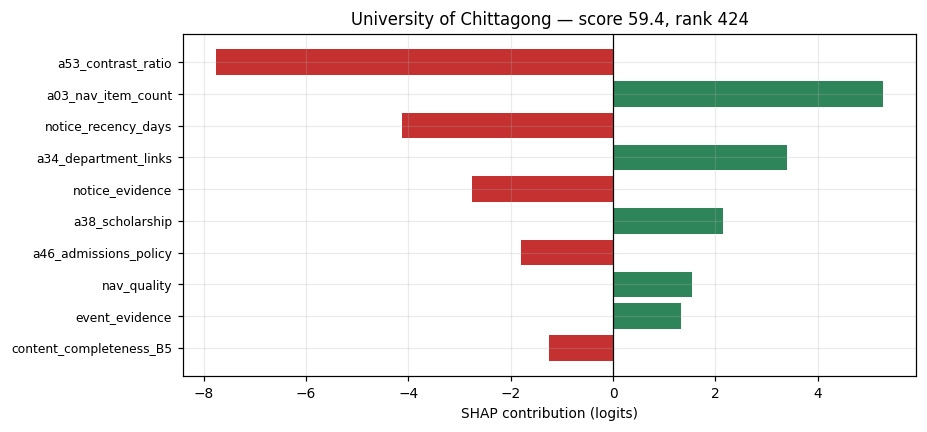

In [25]:
explain("University of Chittagong")

---
# 12. Why is A ranked above B?

In [26]:
def compare(qa, qb, k=8):
    ra = RANKED[RANKED.name.str.contains(qa, case=False, na=False)].iloc[0]
    rb = RANKED[RANKED.name.str.contains(qb, case=False, na=False)].iloc[0]
    ia, ib = UID_ROW[ra.uni_id], UID_ROW[rb.uni_id]
    d = pd.Series(sv_full[ia] - sv_full[ib], index=FEATURES)
    d = d.reindex(d.abs().sort_values(ascending=False).index)
    gap = ra.predicted_score - rb.predicted_score

    print(f"A: {ra['name']}  — score {ra.predicted_score:.1f}, rank {int(ra.global_rank)}")
    print(f"B: {rb['name']}  — score {rb.predicted_score:.1f}, rank {int(rb.global_rank)}")
    print(f"\nScore gap: {gap:+.1f} points. The {k} attributes that explain most of it:\n")
    print(f"  {'effect':>8}  {'attribute':<28} {'A':>10} {'B':>10}   favours")
    for f, v in d.head(k).items():
        print(f"  {v:>+8.3f}  {f:<28} {full.iloc[ia][f]:>10g} {full.iloc[ib][f]:>10g}   "
              f"{'A' if v > 0 else 'B'}")

compare("Khulna University of Engineering", "Bangladesh University of Engineering")

A: Khulna University of Engineering and Technology  — score 85.9, rank 31
B: Bangladesh University of Engineering and Technology  — score 50.0, rank 600

Score gap: +35.8 points. The 8 attributes that explain most of it:

    effect  attribute                             A          B   favours
    +9.430  a46_admissions_policy                 1          0   A
    +6.955  content_completeness_B5        0.866667   0.733333   A
    +4.321  notice_evidence                       3          2   A
    +4.221  notice_recency_days                  30        260   A
    +3.225  a43_contact_link                      1          0   A
    -2.561  a03_nav_item_count                    6          9   B
    +1.322  a66_broken_links                      0          6   A
    +1.265  a34_department_links                  1          1   A


---
# 13. Summary

### What was built

A model that reads 78 measurable attributes of a university landing page and returns a
0–100 quality score, validated against 900 blind human-style pairwise judgments.

### Results

In [27]:
# the over/under-weighted blocks are read from the ranking artefacts, not asserted
RM = json.loads((PROV / "ranking_meta.json").read_text(encoding="utf-8"))
BW = pd.read_csv(PROV / "trackA_block_weights.csv").set_index("block")["mean_weight_pct"]
SH = pd.Series(RM["shap_block_shares"])
BLK = pd.DataFrame({"declared": BW, "realised": SH}).dropna()
BLK["ratio"] = BLK.realised / BLK.declared
BLK = BLK.sort_values("ratio")
OVER, UNDER = BLK.index[0], BLK.index[-1]           # largest mis-allocation each way
W_DECL, W_REAL, W_RAT = BLK.loc[OVER, ["declared", "realised", "ratio"]]
U_DECL, U_REAL, U_RAT = BLK.loc[UNDER, ["declared", "realised", "ratio"]]
WORST_OVER  = OVER.split("_", 1)[1].replace("_", " ")
WORST_UNDER = UNDER.split("_", 1)[1].replace("_", " ")
A11Y_D, A11Y_R = BLK.loc["B11_accessibility", ["declared", "realised"]]

print(f"""
  DATA
    universities scored               {len(full):,}
    expert-labelled (ground truth)    200   -> train {len(train)} / test {len(test)}
    features                          {len(FEATURES)}
    countries with a country ranking  {int(RANKED.country_rank.notna().sum())} universities across {ct.shape[0]} countries

  LABEL QUALITY
    blind pairwise judgments          {BT['n_judgments']}  (relabelled - see section 3)
    self-consistency (swapped repeats) {BT['self_consistency']:.1%}
    Spearman(rubric, judgment)        {BT['spearman_A_B']:.3f}  -> correlated but NOT a formula

  MODEL — {BEST}
    5-fold CV on train      Spearman  {comparison.iloc[0].spearman:.3f}
    HELD-OUT TEST (n=40)    Spearman  {test_metrics['Spearman ρ (rank agreement)']:.3f}
                            R²        {test_metrics['R²']:.3f}
                            MAE       {test_metrics['MAE (points on 0–100)']:.1f} points
    Leave-one-region-out    Spearman  {loro.spearman.mean():.3f}
    Rule-based baseline     Spearman  {comparison[comparison.model.str.contains('rubric')].iloc[0].spearman:.3f}  <- the bar we had to clear

  KEY FINDING
    The rubric declared {WORST_OVER} as {W_DECL:.1f}% of website quality;
    SHAP shows it actually drives {W_REAL:.1f}% - roughly {1/W_RAT:.0f}x less than assigned.
    {WORST_UNDER} was declared {U_DECL:.1f}% and drives {U_REAL:.1f}% - {U_RAT:.1f}x more.
    Accessibility is the sharpest case: declared {A11Y_D:.1f}%, drives {A11Y_R:.1f}%. The first
    labelling pass inflated it, because the profile cards advertised alt-text coverage as a
    headline number; once the judge was asked a prospective applicant's question instead,
    it collapsed.
    Hand-set weights misallocate importance across quality dimensions, and measuring the
    realised influence is what shows it.
""")


  DATA
    universities scored               1,226
    expert-labelled (ground truth)    200   -> train 160 / test 40
    features                          78
    countries with a country ranking  797 universities across 19 countries

  LABEL QUALITY
    blind pairwise judgments          900  (relabelled - see section 3)
    self-consistency (swapped repeats) 96.7%
    Spearman(rubric, judgment)        0.814  -> correlated but NOT a formula

  MODEL — LightGBM (monotonic)
    5-fold CV on train      Spearman  0.863
    HELD-OUT TEST (n=40)    Spearman  0.922
                            R²        0.818
                            MAE       9.0 points
    Leave-one-region-out    Spearman  0.839
    Rule-based baseline     Spearman  0.792  <- the bar we had to clear

  KEY FINDING
    The rubric declared seo metadata as 3.6% of website quality;
    SHAP shows it actually drives 0.7% - roughly 6x less than assigned.
    visual design was declared 3.4% and drives 6.0% - 1.7x more.
    Acce

### Honest limitations

1. The labels are **expert-style judgments made from extracted attribute profiles**, not
   ratings of live websites by a panel of humans. Visual design, tone, and whether links
   truly work are invisible to both the labels and the model.
2. **One rater.** Self-consistency is measured (96.7% on swapped repeats); inter-rater
   agreement cannot be, because there is only one rater.
3. **No external validation** against QS, Webometrics, or a student survey was performed,
   so no claim of agreement with real user perception is made.
4. **Collector and region are perfectly confounded** — each of the six data collectors
   covered exactly one region. Regional score differences could be real quality differences
   or measurement differences, and this dataset cannot separate them. The model's *accuracy*
   is stable across regions (LORO ρ = 0.81–0.87), so the ranking is not a regional lookup
   table, but the regional ranking is the safer artefact to quote.
5. **200 labelled of 1,226.** The other 1,026 scores are model inference.
6. **The dataset cannot see design.** Every feature is a presence flag, a count, or a
   measurement. Whether a page is cluttered, dated-looking, or simply unpleasant to use
   is not in the 78 columns, so it cannot be in the score. A site that ticks every
   content box will rank highly even if a human would find it ugly. This is the single
   largest gap between this ranking and a real user's impression, and closing it would
   require screenshots and human raters rather than more modelling.

### Output files

In [28]:
OUTDIR = BASE / "outputs_from_notebook"
OUTDIR.mkdir(exist_ok=True)
comparison.to_csv(OUTDIR / "model_comparison.csv", index=False)
pd.DataFrame([test_metrics]).to_csv(OUTDIR / "test_set_metrics.csv", index=False)
imp.to_csv(OUTDIR / "feature_importance.csv", index=False)
loro.to_csv(OUTDIR / "leave_one_region_out.csv", index=False)
RANKED[["global_rank", "name", "country", "predicted_score", "grade",
        "country_rank", "percentile"]].to_csv(OUTDIR / "final_ranking.csv", index=False)
print(f"written to {OUTDIR.name}/:")
for p in sorted(OUTDIR.glob("*.csv")):
    print(f"  {p.name}")
print("\nNotebook complete.")

written to outputs_from_notebook/:
  feature_importance.csv
  final_ranking.csv
  leave_one_region_out.csv
  model_comparison.csv
  test_set_metrics.csv

Notebook complete.
